# Experiment 002 - Machine Forward Adaptive Stride

Step: `machine_forward_08_true_delta`

Goal: check whether adaptive latent-motion stride fixes the weak one-step delta target from run 001.

## Plot

![True delta histogram adaptive stride](true_delta_histogram_adaptive_stride.png)

In [1]:
from pathlib import Path
import torch
import matplotlib.pyplot as plt

student_root = Path.cwd()
while student_root.name != "Student":
    if student_root.parent == student_root:
        raise RuntimeError("Run this notebook inside the Student project tree")
    student_root = student_root.parent

probe_path = student_root / "runs/action_inference/machine_forward/machine_probe_dataset.pt"
probe = torch.load(probe_path, map_location="cpu")
dz = probe["dz"].float()
stride = probe.get("stride")

stats = {
    "shape": tuple(dz.shape),
    "mean": float(dz.mean().item()),
    "std": float(dz.std(unbiased=False).item()),
    "abs_mean": float(dz.abs().mean().item()),
    "norm_mean": float(dz.norm(dim=-1).mean().item()),
    "min": float(dz.min().item()),
    "max": float(dz.max().item()),
}

if stride is not None:
    stride = stride.float()
    stats.update({
        "stride_mean": float(stride.mean().item()),
        "stride_min": float(stride.min().item()),
        "stride_max": float(stride.max().item()),
    })

stats

{'shape': (5279, 64),
 'mean': -2.881274667743128e-07,
 'std': 0.02837188169360161,
 'abs_mean': 0.021123072132468224,
 'norm_mean': 0.2153582125902176,
 'min': -0.23944276571273804,
 'max': 0.2437717318534851,
 'stride_mean': 1.9122940301895142,
 'stride_min': 1.0,
 'stride_max': 8.0}

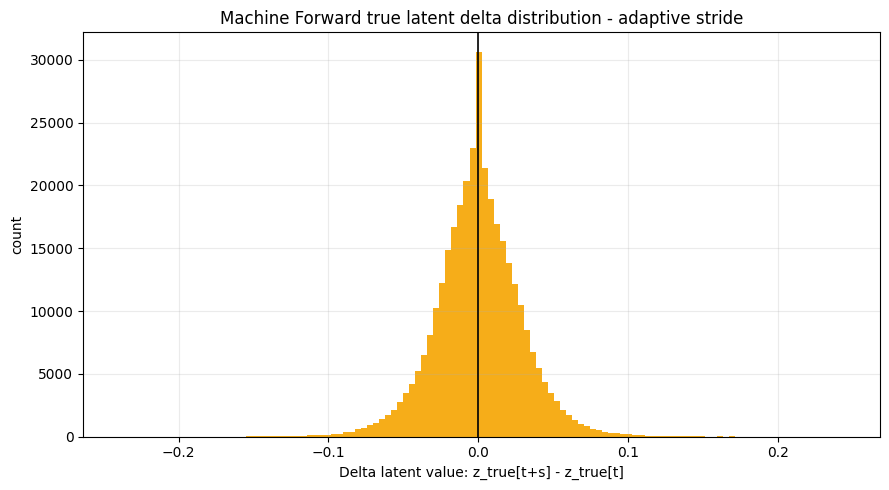

In [2]:
plt.figure(figsize=(9, 5))
plt.hist(dz.flatten().numpy(), bins=120, color="#f5a400", alpha=0.9)
plt.axvline(0.0, color="black", linewidth=1.2)
plt.title("Machine Forward true latent delta distribution - adaptive stride")
plt.xlabel("Delta latent value: z_true[t+s] - z_true[t]")
plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Summary

Adaptive stride did what it was supposed to do: it made the real action produce a stronger latent transition.

| Metric | Run 001 vanilla | Run 002 adaptive stride |
|---|---:|---:|
| true delta std | `0.016482` | `0.028372` |
| true delta abs mean | `0.009892` | `0.021123` |
| true delta mean vector norm | `0.100751` | `0.215358` |
| eval delta cosine | `0.571591` | `0.682763` |
| train zero / machine | `3.135124` | `3.426886` |
| eval zero / machine | `3.266310` | `2.087072` |

The absolute MSE is higher in run 002 because the target delta is larger. That is expected. The important checks are that `zero_baseline` is higher, `zero_over_machine` stays above `1`, and `delta_cos` improves.

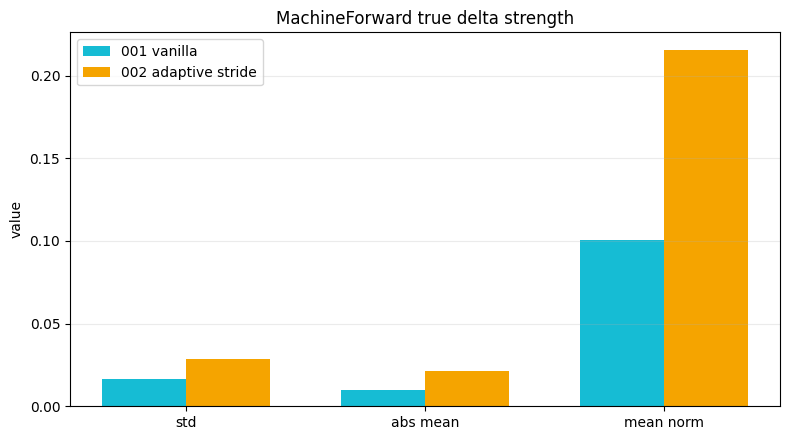

In [3]:
import matplotlib.pyplot as plt

labels = ["std", "abs mean", "mean norm"]
run_001 = [0.016482, 0.009892, 0.100751]
run_002 = [0.028372, 0.021123, 0.215358]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(8, 4.5))
plt.bar([i - width / 2 for i in x], run_001, width, label="001 vanilla", color="#16bcd4")
plt.bar([i + width / 2 for i in x], run_002, width, label="002 adaptive stride", color="#f5a400")
plt.xticks(list(x), labels)
plt.title("MachineForward true delta strength")
plt.ylabel("value")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("true_delta_strength_comparison.png", dpi=160)
plt.show()

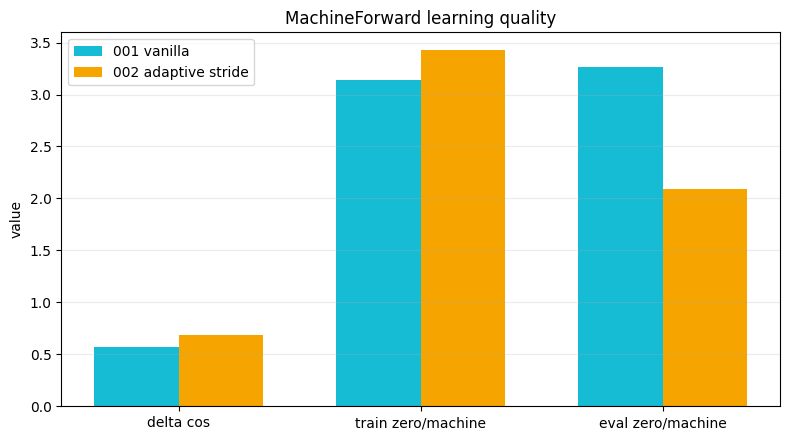

In [4]:
labels = ["delta cos", "train zero/machine", "eval zero/machine"]
run_001 = [0.571591, 3.135124, 3.266310]
run_002 = [0.682763, 3.426886, 2.087072]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(8, 4.5))
plt.bar([i - width / 2 for i in x], run_001, width, label="001 vanilla", color="#16bcd4")
plt.bar([i + width / 2 for i in x], run_002, width, label="002 adaptive stride", color="#f5a400")
plt.xticks(list(x), labels)
plt.title("MachineForward learning quality")
plt.ylabel("value")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("machine_forward_quality_comparison.png", dpi=160)
plt.show()

## TensorBoard Checks

The TensorBoard pass confirms the same result:

* `machine_forward_08_true_delta`: wider distribution, larger `std`, larger `norm`.
* `machine_forward_09_pred_delta`: predicted delta also grows, so the model is not collapsing to zero.
* `machine_forward/delta_cos`: run 002 is clearly better than run 001.
* `loss/zero_baseline`: higher in run 002, which is expected because the target is no longer almost zero.
* `machine_forward/zero_over_machine`: still above `1`, so MachineForward beats the zero baseline.

## Decision

MachineForward adaptive stride is accepted.

The weak true-delta bottleneck from run 001 is fixed enough to move forward. Next experiment should continue with Runtime Control and check whether the stronger MachineForward model improves real action search and rollout reward.